In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings as wr
wr.filterwarnings('ignore')

df = pd.read_csv('./styles.csv', on_bad_lines='skip')
df.head()
print("hi")

hi


In [2]:
df.dtypes

id                      int64
gender                 object
masterCategory         object
subCategory            object
articleType            object
baseColour             object
season                 object
year                  float64
usage                  object
productDisplayName     object
dtype: object

In [4]:
print(df.head())

      id gender masterCategory subCategory  articleType baseColour  season  \
0  15970    Men        Apparel     Topwear       Shirts  Navy Blue    Fall   
1  39386    Men        Apparel  Bottomwear        Jeans       Blue  Summer   
2  59263  Women    Accessories     Watches      Watches     Silver  Winter   
3  21379    Men        Apparel  Bottomwear  Track Pants      Black    Fall   
4  53759    Men        Apparel     Topwear      Tshirts       Grey  Summer   

     year   usage                             productDisplayName  
0  2011.0  Casual               Turtle Check Men Navy Blue Shirt  
1  2012.0  Casual             Peter England Men Party Blue Jeans  
2  2016.0  Casual                       Titan Women Silver Watch  
3  2011.0  Casual  Manchester United Men Solid Black Track Pants  
4  2012.0  Casual                          Puma Men Grey T-shirt  


In [5]:
df.shape

(44424, 10)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44424 entries, 0 to 44423
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  44424 non-null  int64  
 1   gender              44424 non-null  object 
 2   masterCategory      44424 non-null  object 
 3   subCategory         44424 non-null  object 
 4   articleType         44424 non-null  object 
 5   baseColour          44409 non-null  object 
 6   season              44403 non-null  object 
 7   year                44423 non-null  float64
 8   usage               44107 non-null  object 
 9   productDisplayName  44417 non-null  object 
dtypes: float64(1), int64(1), object(8)
memory usage: 3.4+ MB


In [7]:
df.describe()

,id,year
count,44424.000000,44423.000000
mean,29696.334301,2012.806497
std,17049.490518,2.126480
min,1163.000000,2007.000000
25%,14768.750000,2011.000000
50%,28618.500000,2012.000000
75%,44683.250000,2015.000000
max,60000.000000,2019.000000


In [8]:
df.columns.tolist()

['id',
 'gender',
 'masterCategory',
 'subCategory',
 'articleType',
 'baseColour',
 'season',
 'year',
 'usage',
 'productDisplayName']

In [9]:
df.isnull().sum()

id                      0
gender                  0
masterCategory          0
subCategory             0
articleType             0
baseColour             15
season                 21
year                    1
usage                 317
productDisplayName      7
dtype: int64

In [10]:
df.nunique()

id                    44424
gender                    5
masterCategory            7
subCategory              45
articleType             143
baseColour               46
season                    4
year                     13
usage                     8
productDisplayName    31121
dtype: int64

# Assuming 'df' is your DataFrame
df['gender'] = df['gender'].astype(str)  # Convert 'quality' to categorical

plt.figure(figsize=(10, 8))

# Using Seaborn to create a violin plot
sns.violinplot(x="gender", y="articleType", data=df, palette={
               'Men': 'lightcoral', 'Women': 'lightblue', 'Boys': 'lightgreen', 'Girls': 'gold', 'Unisex': 'lightskyblue'}, alpha=0.7)

plt.title('Violin Plot for Gender and Article Type')
plt.xlabel('Gender')
plt.ylabel('Article Type')
plt.show()


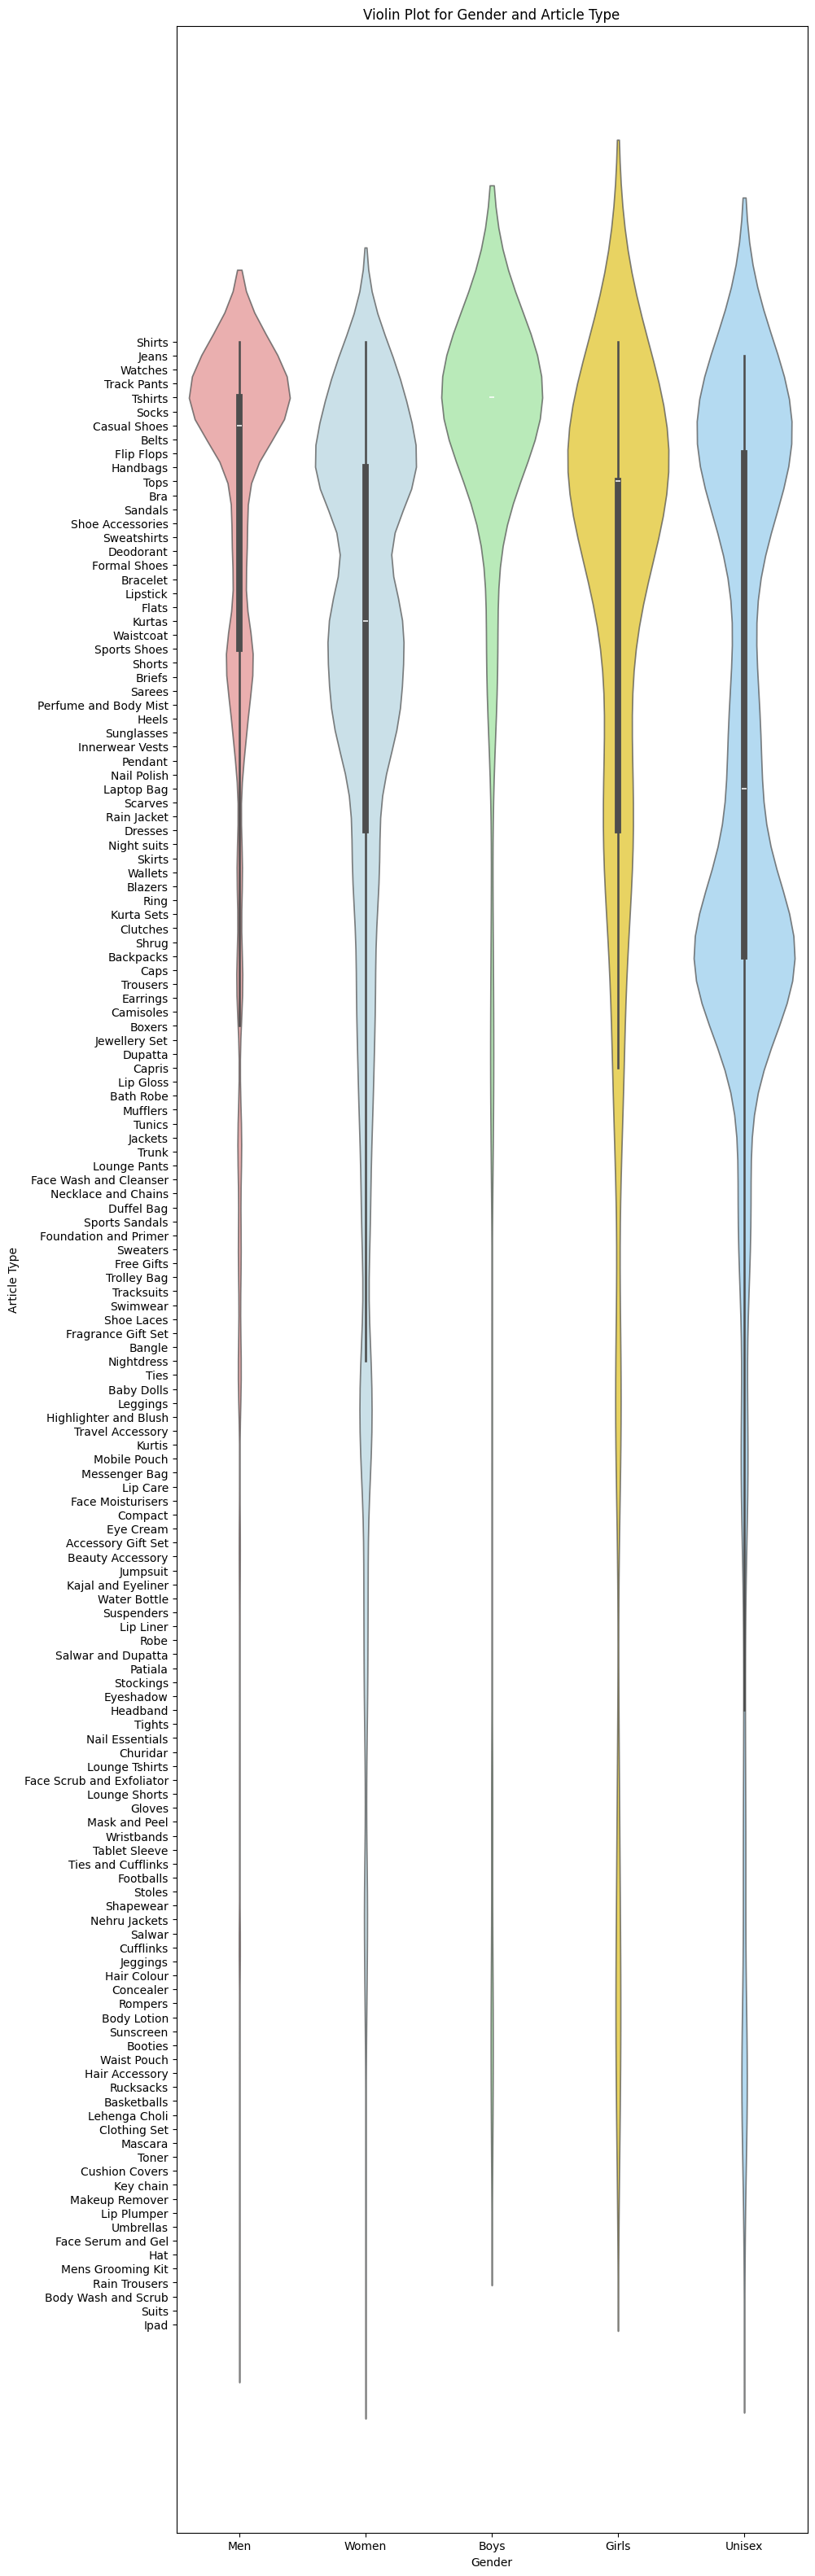

In [19]:
# Assuming 'df' is your DataFrame
df['gender'] = df['gender'].astype(str)  # Convert 'quality' to categorical

plt.figure(figsize=(10, 40))

# Using Seaborn to create a violin plot
sns.violinplot(x="gender", y="articleType", data=df, palette={
               'Men': 'lightcoral', 'Women': 'lightblue', 'Boys': 'lightgreen', 'Girls': 'gold', 'Unisex': 'lightskyblue'}, alpha=0.7)

plt.title('Violin Plot for Gender and Article Type')
plt.xlabel('Gender')
plt.ylabel('Article Type')
plt.show()

<Axes: xlabel='gender', ylabel='articleType'>

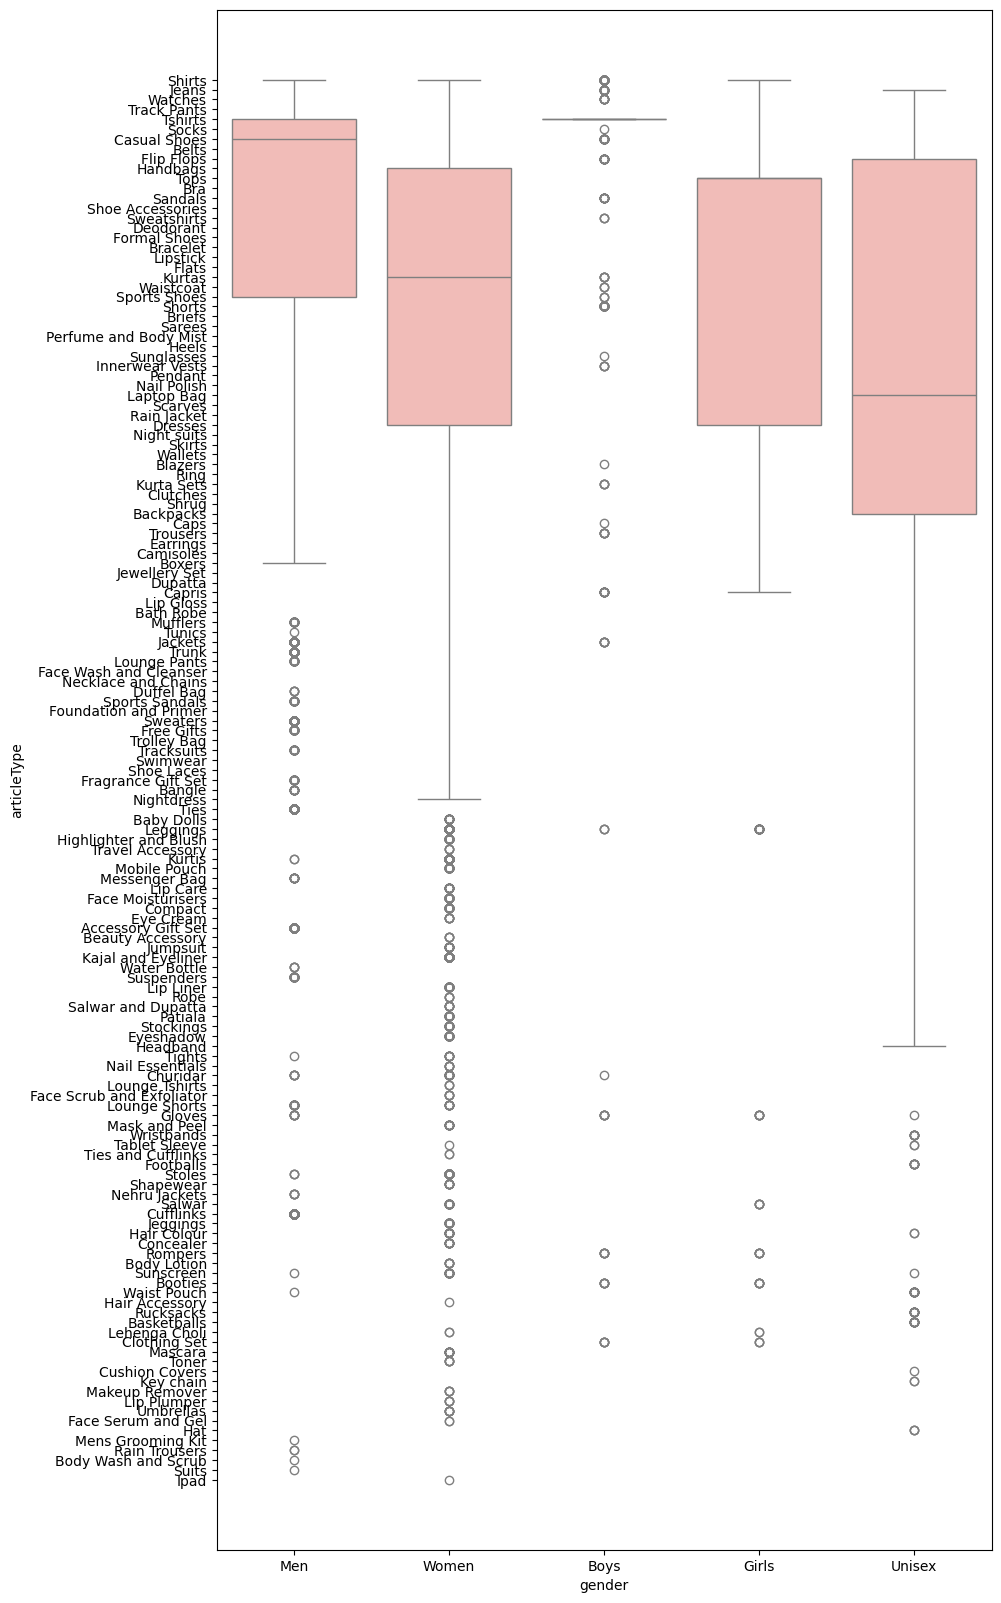

In [6]:
plt.figure(figsize=(10,20))
sns.boxplot(x='gender', y='articleType', data=df)


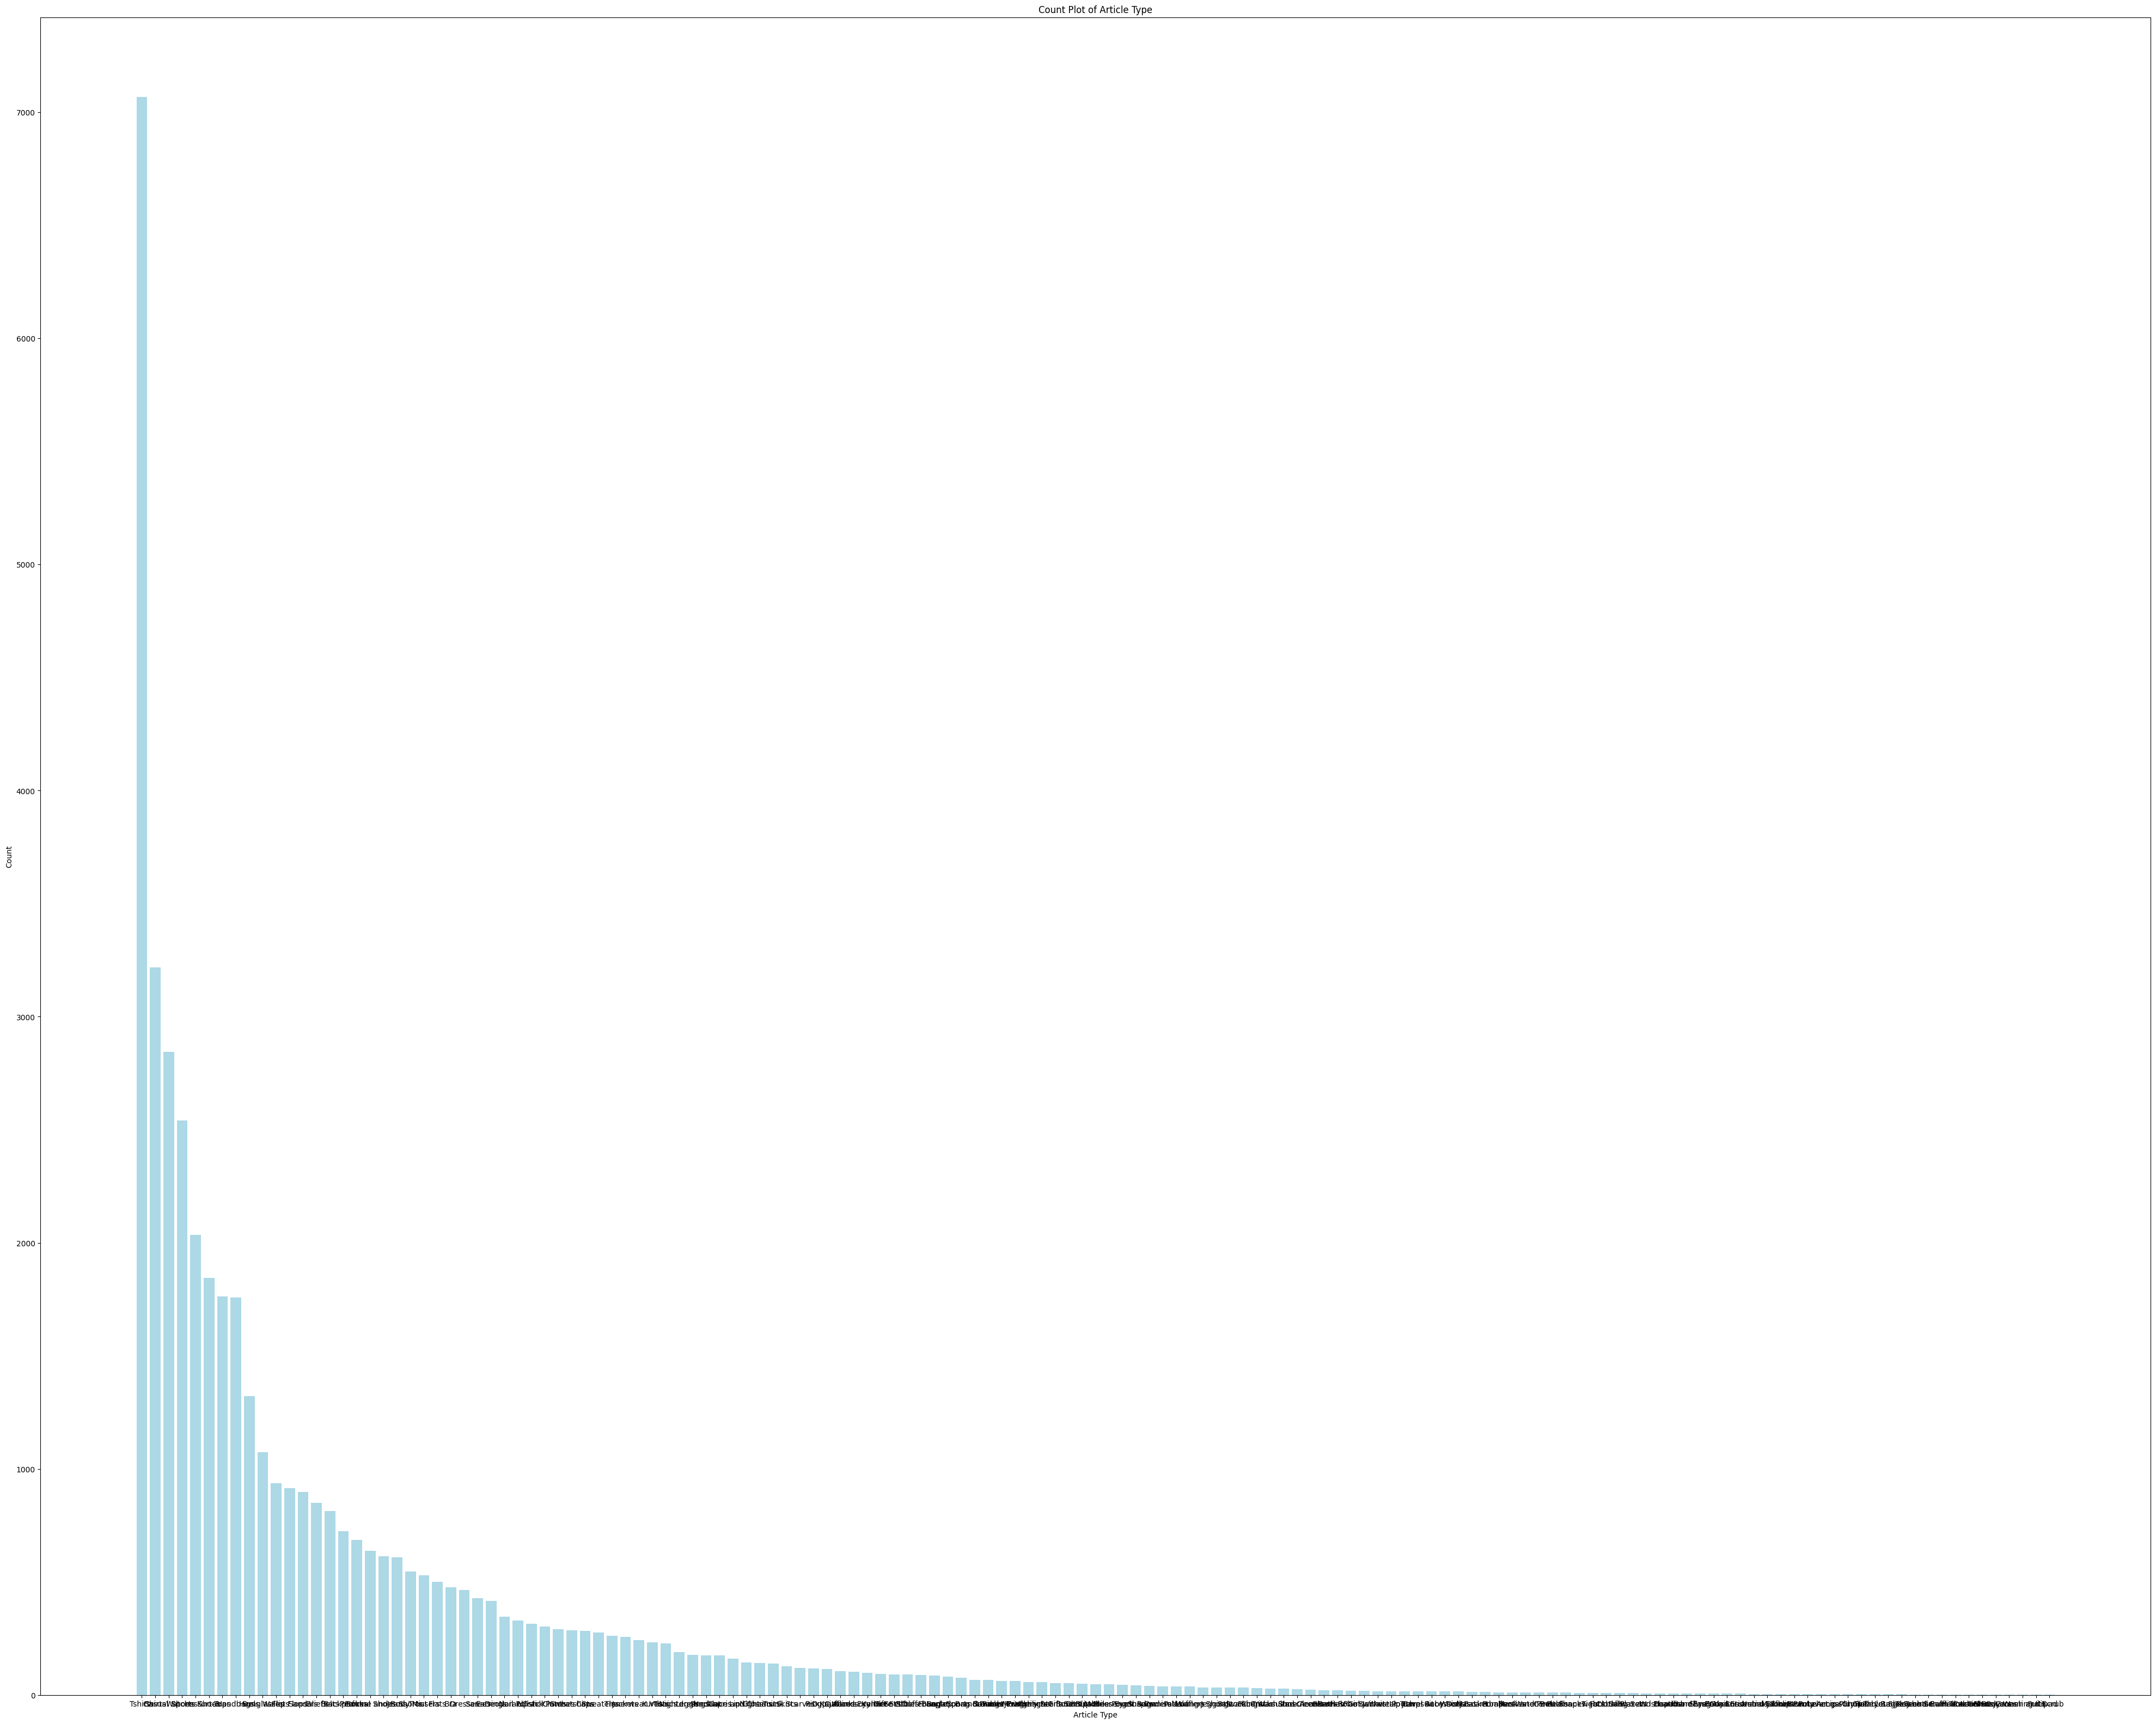

In [33]:
articleType_counts = df['articleType'].value_counts()
plt.figure(figsize=(50, 40))
plt.bar(articleType_counts.index, articleType_counts, color='lightblue')
plt.title('Count Plot of Article Type')
plt.xlabel('Article Type')
plt.ylabel('Count')
plt.show()

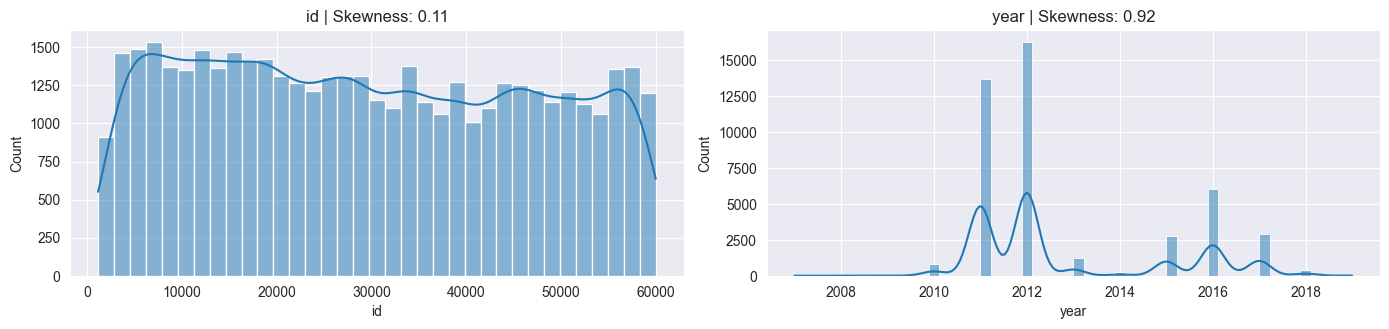

In [34]:
sns.set_style("darkgrid")
numerical_columns = df.select_dtypes(include=["int64", "float64"]).columns
plt.figure(figsize=(14, len(numerical_columns) * 3))
for idx, feature in enumerate(numerical_columns, 1):
    plt.subplot(len(numerical_columns), 2, idx)
    sns.histplot(df[feature], kde=True)
    plt.title(f"{feature} | Skewness: {round(df[feature].skew(), 2)}")
plt.tight_layout()
plt.show()

<Figure size 1000x600 with 0 Axes>

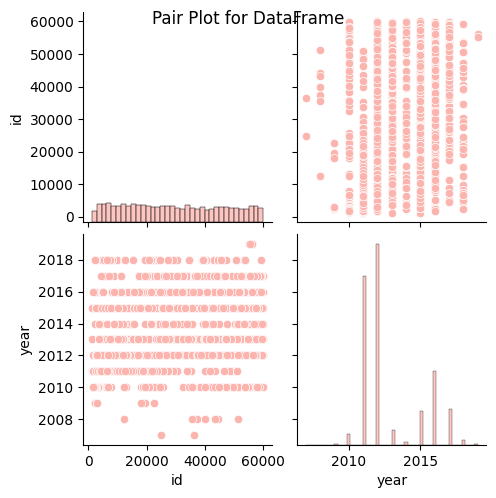

In [3]:
# Set the color palette
sns.set_palette("Pastel1")

# Assuming 'df' is your DataFrame
plt.figure(figsize=(10, 6))

# Using Seaborn to create a pair plot with the specified color palette
sns.pairplot(df)

plt.suptitle('Pair Plot for DataFrame')
plt.show()


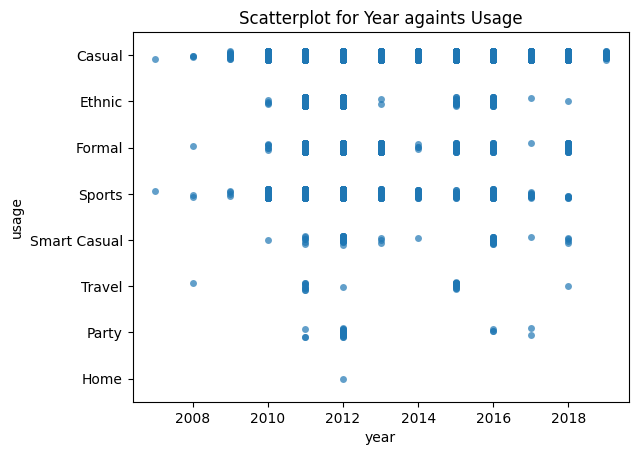

In [7]:

sns.stripplot(data=df, x='year', y='usage', jitter=True, alpha=0.7)
plt.title('Scatterplot for Year againts Usage')
plt.show()

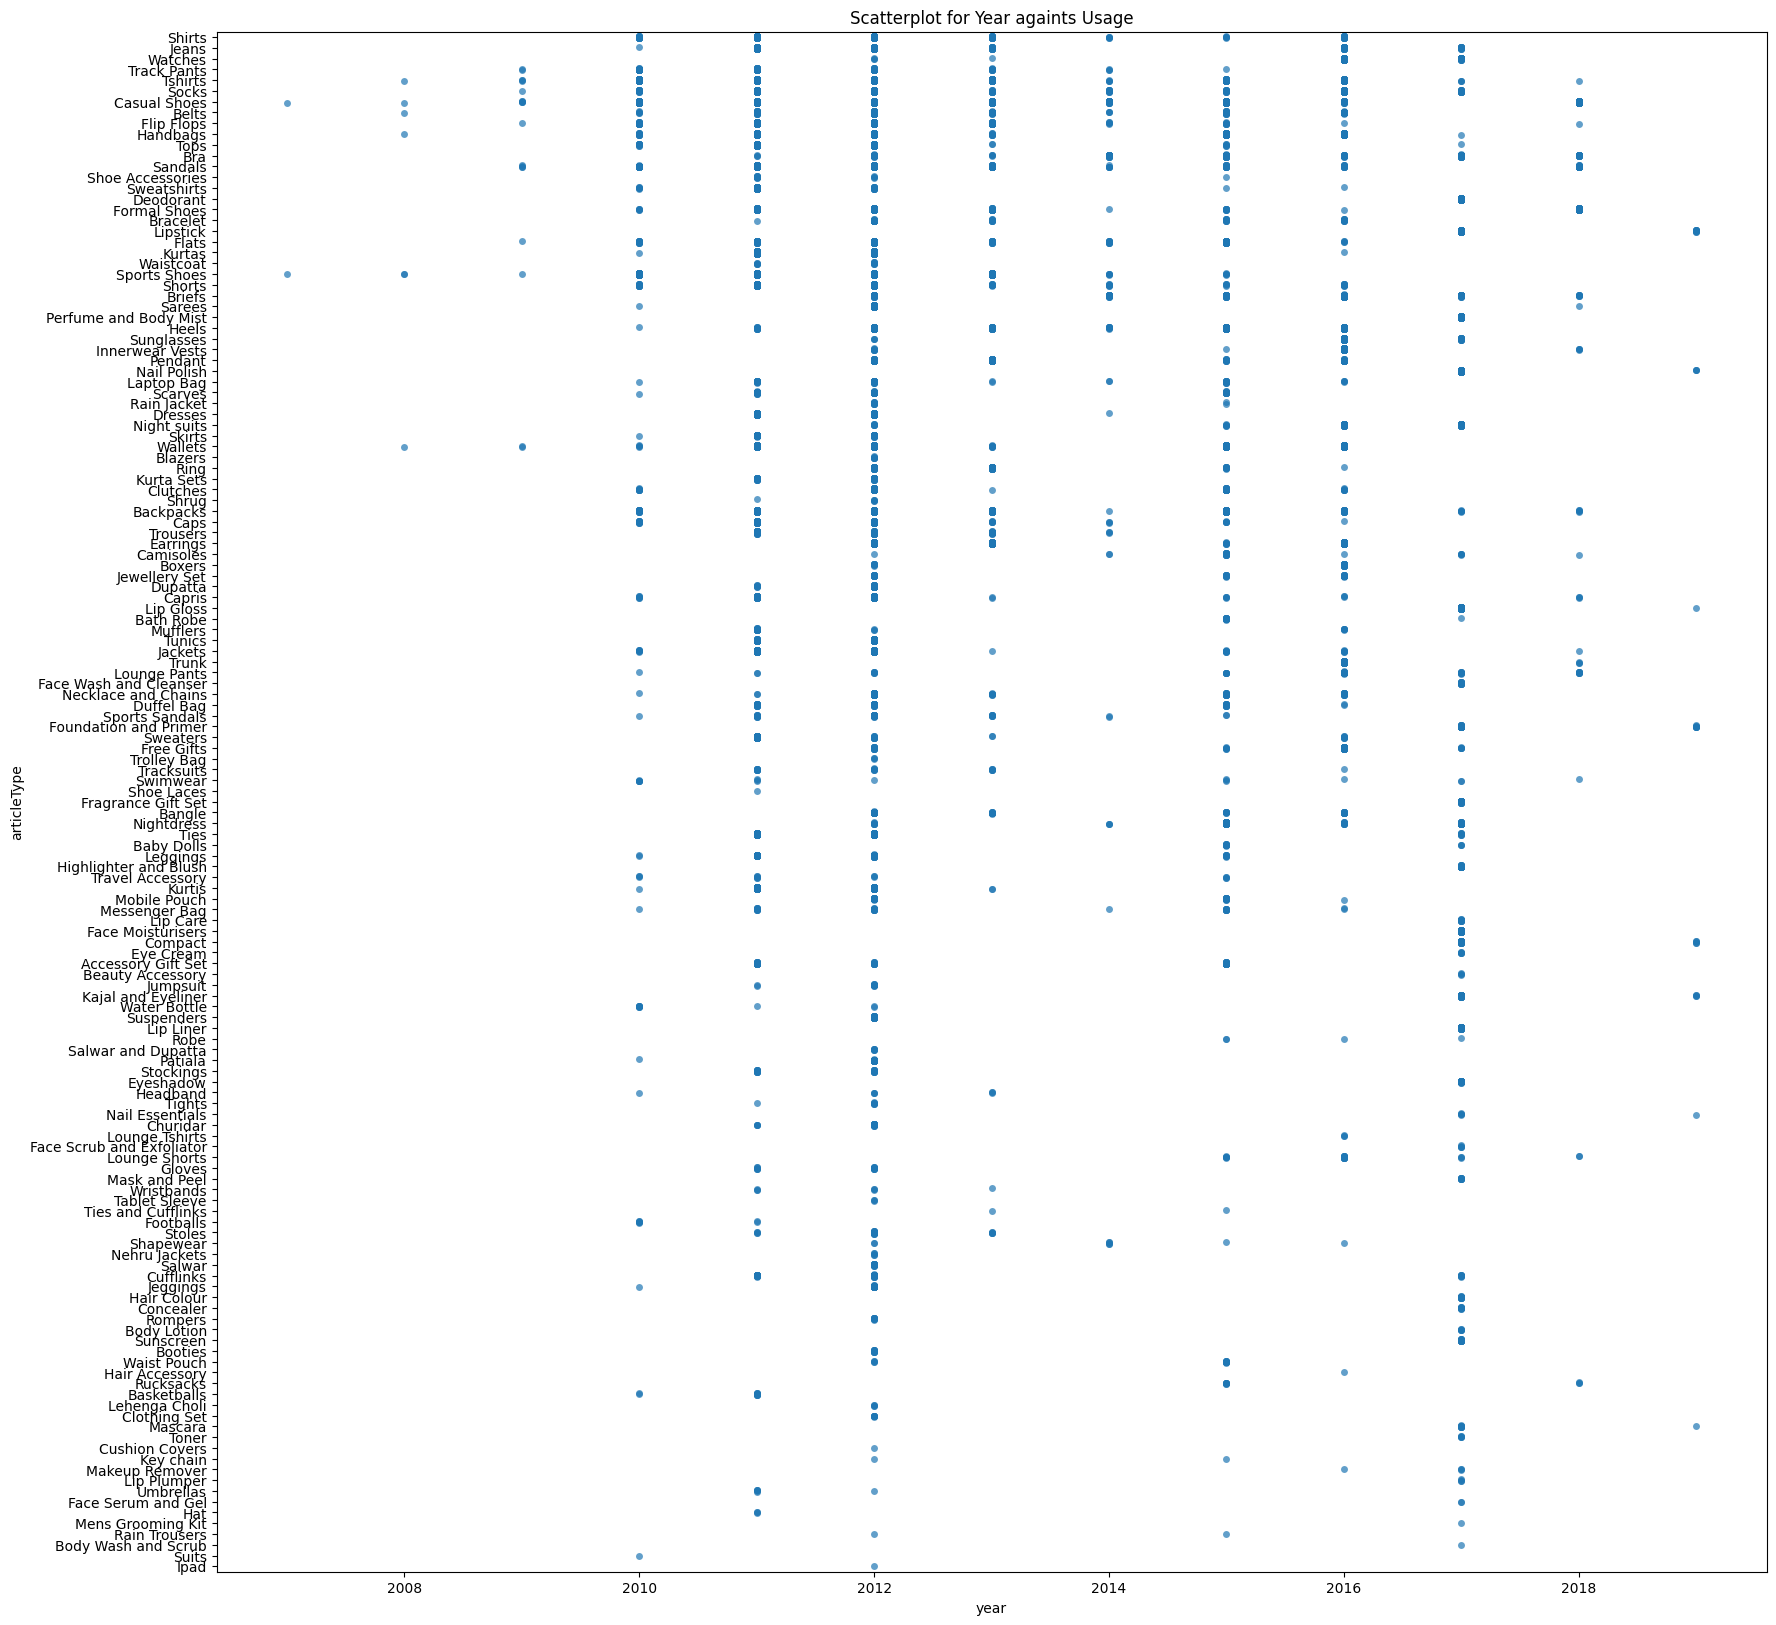

In [8]:
plt.figure(figsize=(20,20))
sns.stripplot(data=df, x='year', y='articleType', jitter=True, alpha=0.7)
plt.title('Scatterplot for Year againts Usage')
plt.show()

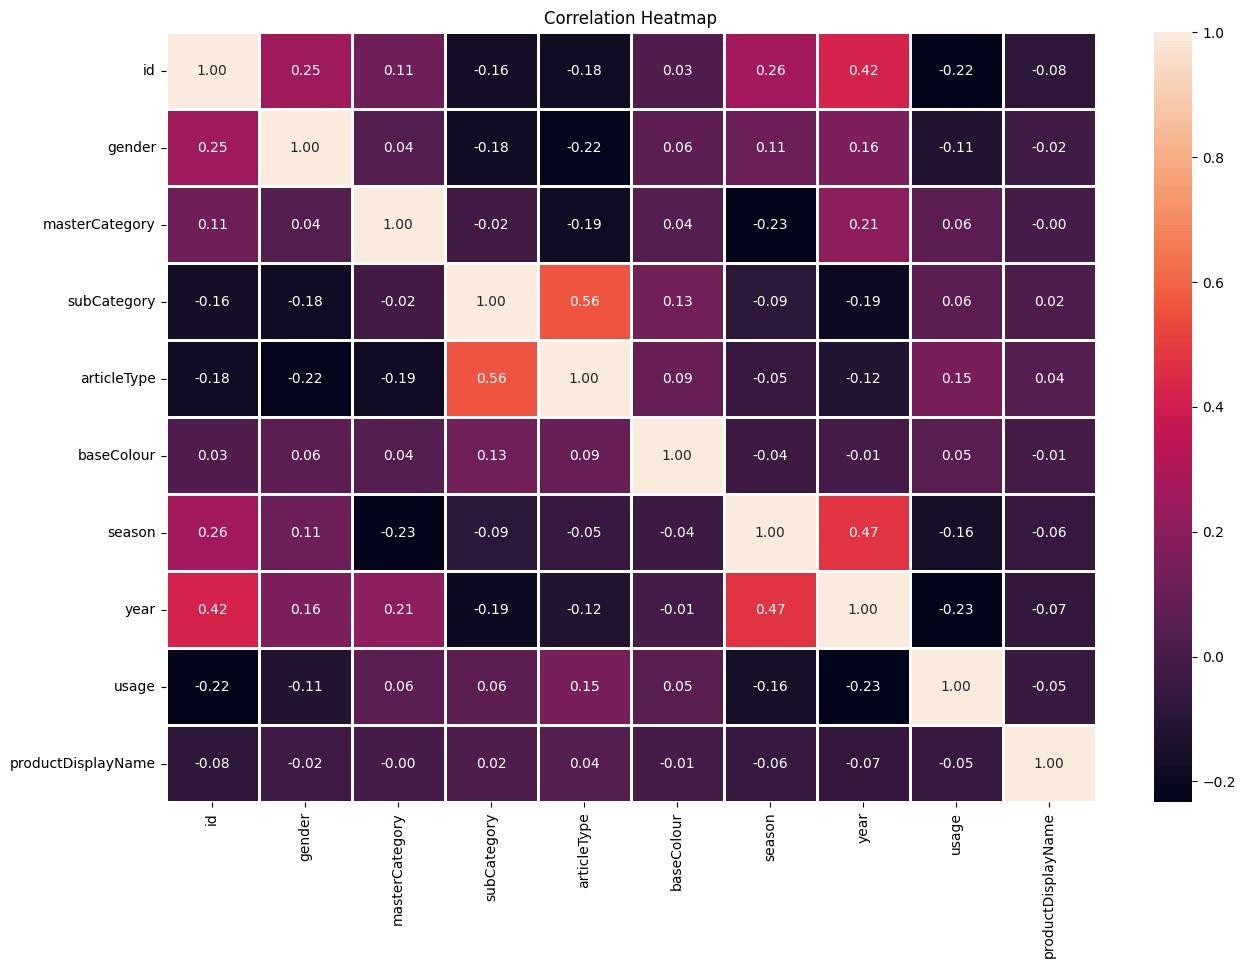

In [6]:
import sklearn
from sklearn.preprocessing import OrdinalEncoder
encoder = OrdinalEncoder()
df_encoded = df.copy()
df_encoded[df.columns] = encoder.fit_transform(df[df.columns])
plt.figure(figsize=(15, 10))
sns.heatmap(df_encoded.corr(), annot=True, fmt='.2f', linewidths=2)
plt.title('Correlation Heatmap')
plt.show()

In [15]:

    plt.figure(figsize=(12, 12))
    top_categories = df.head(top_n)
    others = pd.Series({'Others': df.iloc[top_n:].sum()})
    pie_data = pd.concat([top_categories, others])

    colors = sns.color_palette("husl", len(pie_df))
    plt.pie(pie_df.values, labels=pie_df.index, autopct='%1.1f%%', startangle=90, colors=colors)
    plt.title(f'Top {top_n} Categories', fontsize=28)
    plt.axis('equal')
    


NameError: name 'top_n' is not defined

<Figure size 1200x1200 with 0 Axes>

<Axes: xlabel='year', ylabel='articleType'>

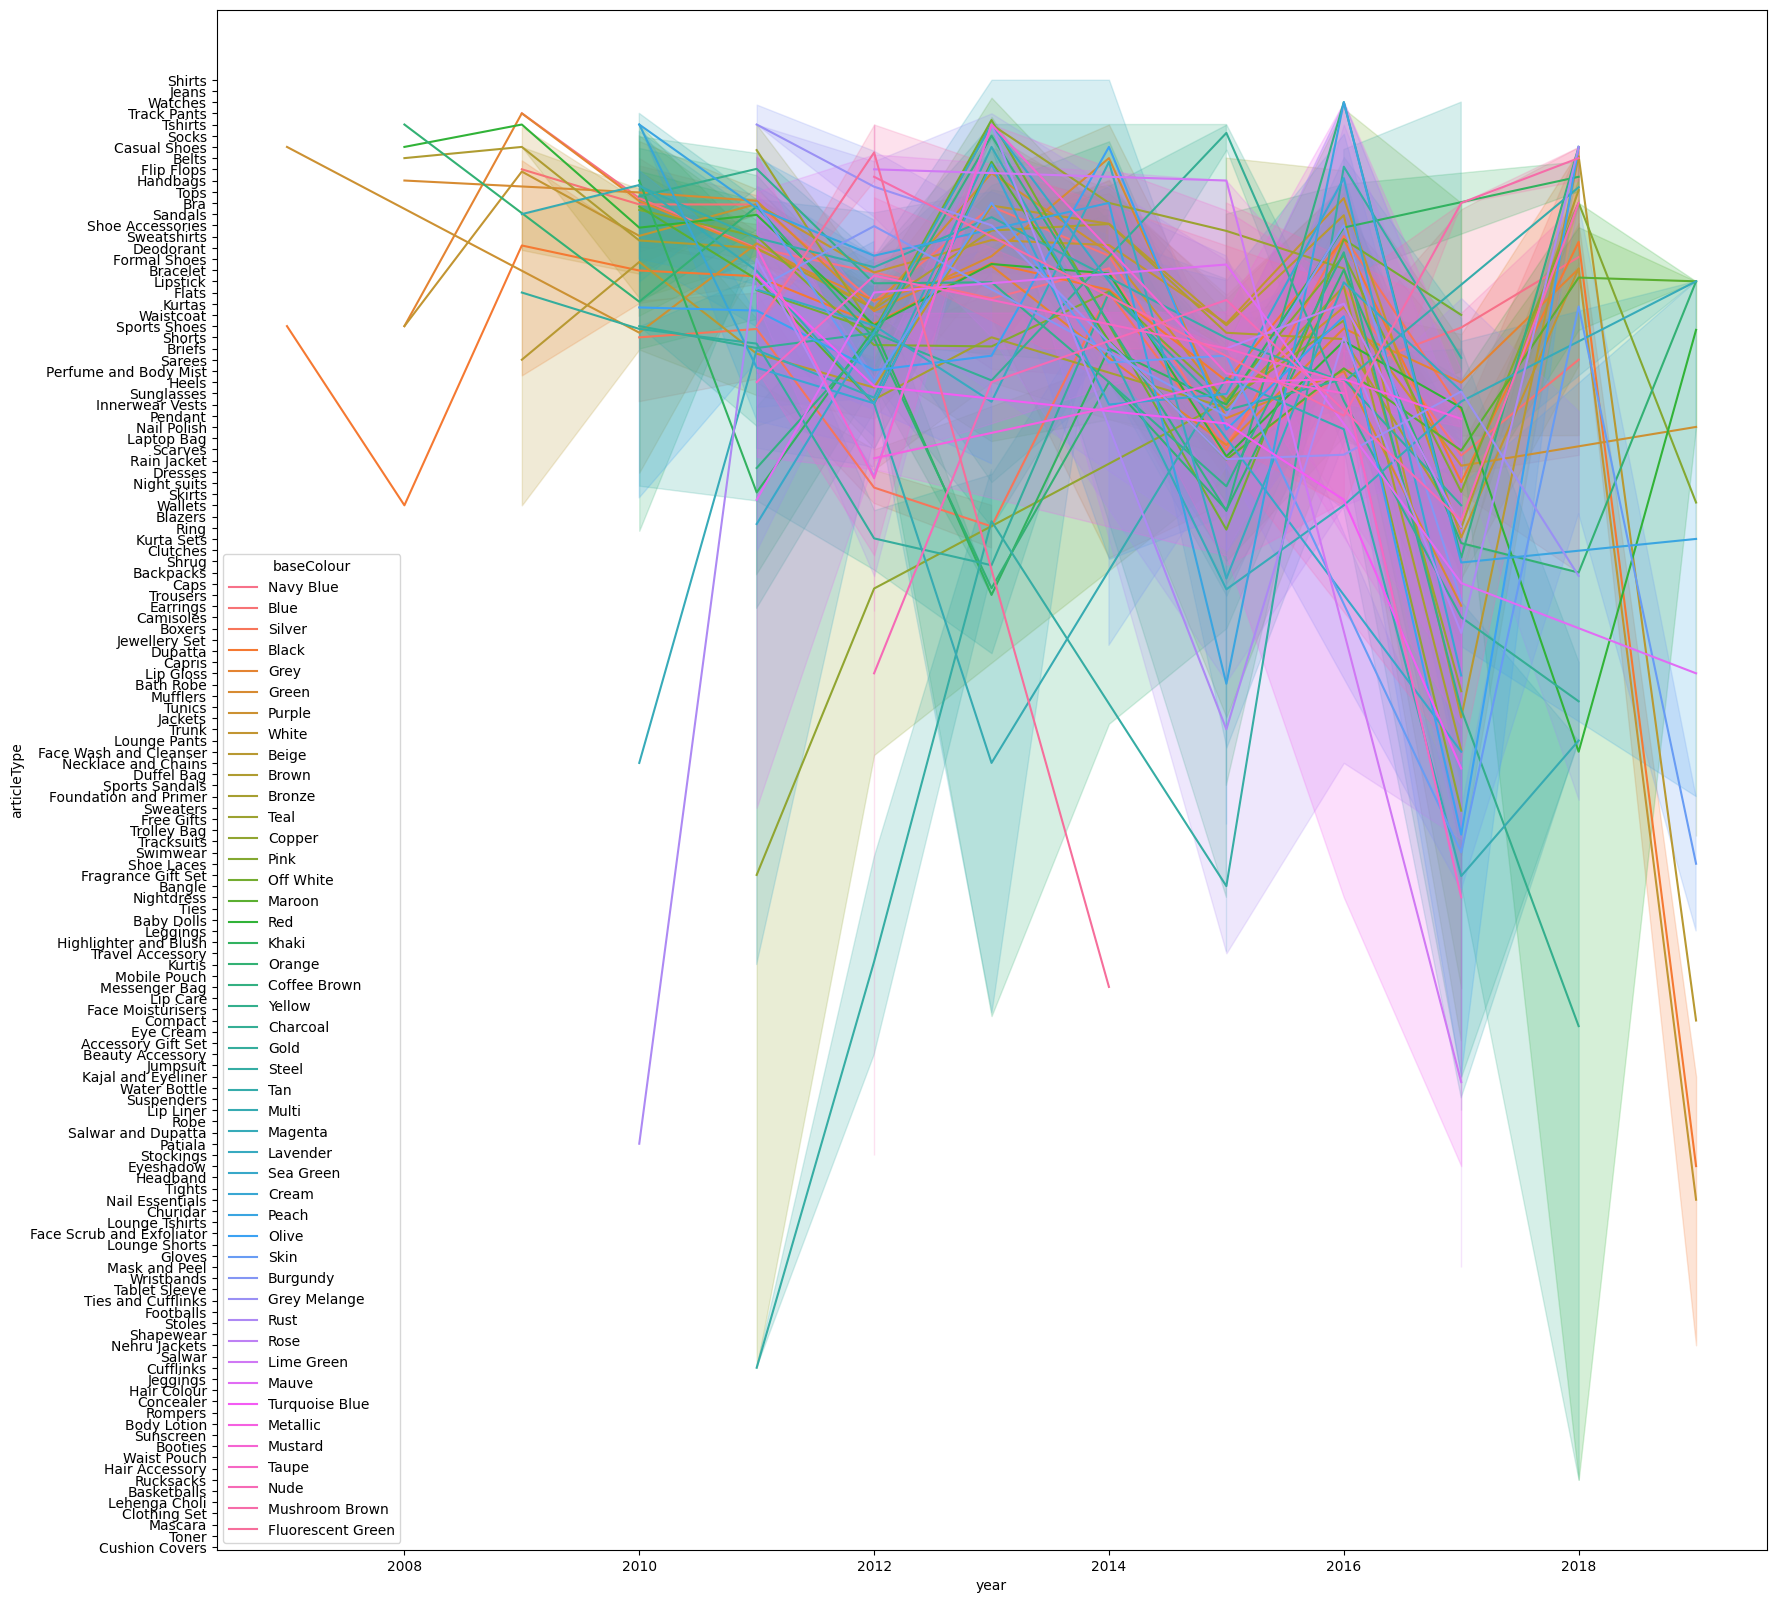

In [2]:
plt.figure(figsize=(20,20))
sns.lineplot(x='year',y='articleType',data=df, hue='baseColour')

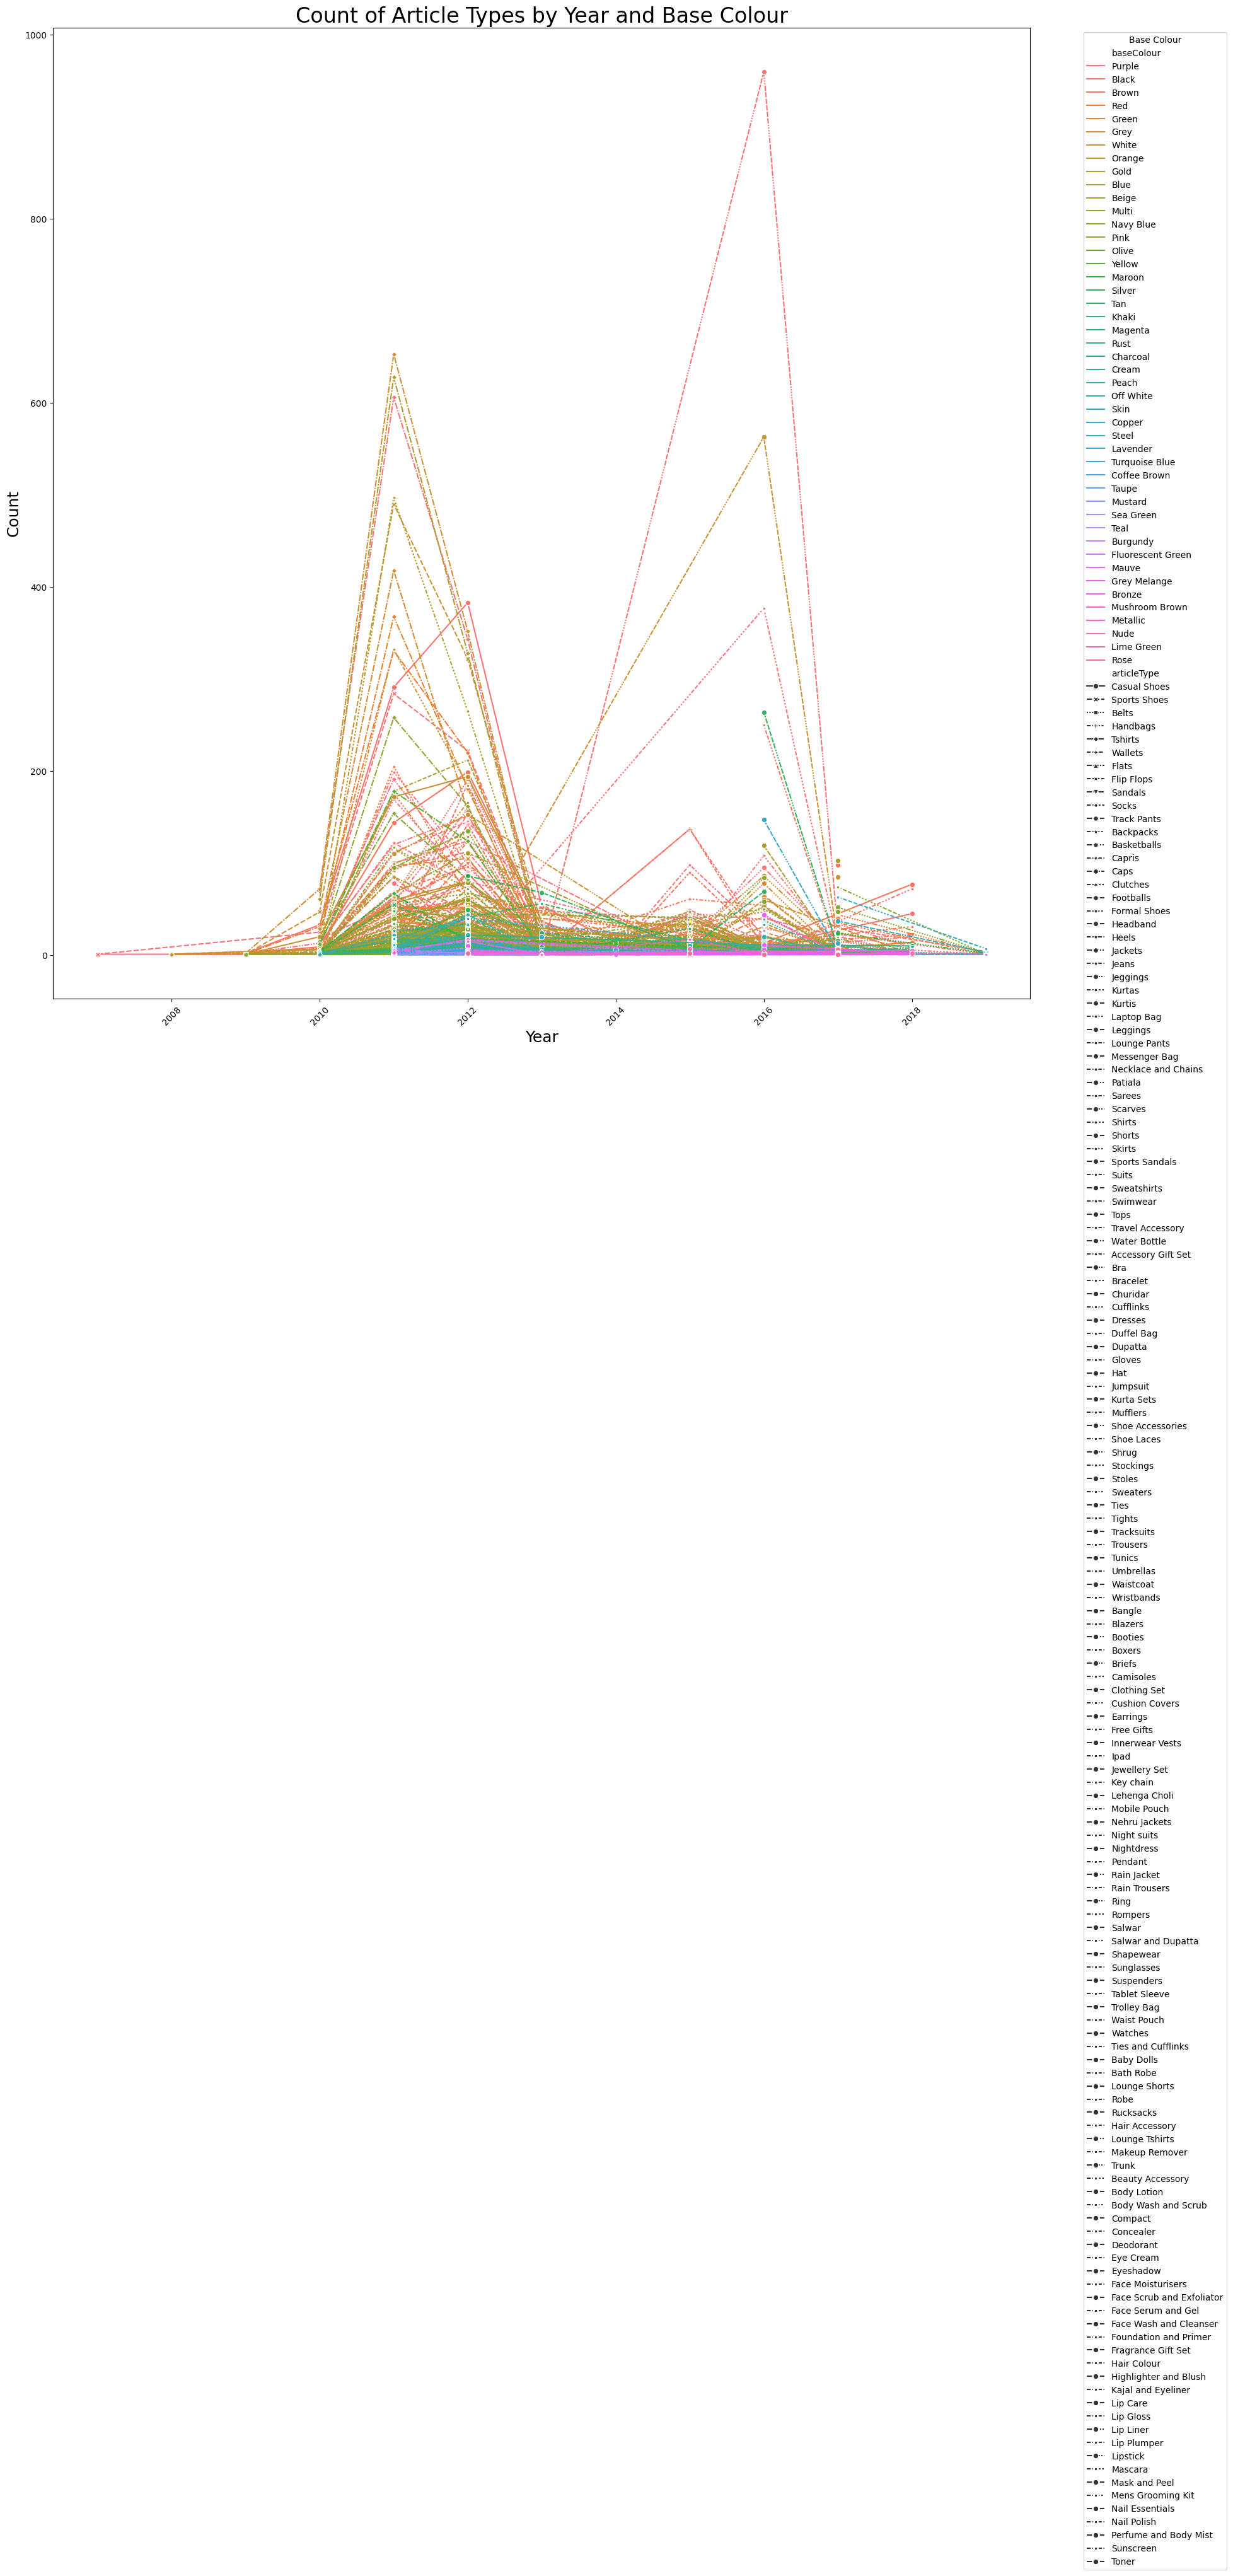

In [3]:
# Count occurrences of each articleType for each year and baseColour
count_data = df.groupby(['year', 'articleType', 'baseColour']).size().reset_index(name='count')

# Create a larger figure for better visibility
plt.figure(figsize=(20, 20))

# Create a line plot with count on the y-axis
sns.lineplot(data=count_data, x='year', y='count', hue='baseColour', style='articleType', markers=True)

# Set title and labels
plt.title('Count of Article Types by Year and Base Colour', fontsize=24)
plt.xlabel('Year', fontsize=18)
plt.ylabel('Count', fontsize=18)

# Rotate x-ticks for better readability
plt.xticks(rotation=45)

# Show the plot
plt.legend(title='Base Colour', bbox_to_anchor=(1.05, 1), loc='upper left')  # Adjust legend position
plt.tight_layout()
plt.show() 

In [17]:
import plotly.express as px

# Assuming you already have your DataFrame df loaded
# Group the data to count occurrences of baseColour for each year
count_data = df.groupby(['year', 'baseColour']).size().reset_index(name='count')

# Create an interactive line plot
fig = px.line(
    count_data,
    x='year',
    y='count',
    color='baseColour',  # Color by baseColour
    markers=True,        # Add markers to the lines
    title='Count of Base Colour by Year'
)

# Update layout for better visualization
fig.update_layout(
    xaxis_title='Year',
    yaxis_title='Count',
    legend_title='Base Colour',
    hovermode='x unified',  # Unified hover for better readability
    height=800               # Set the height to your desired value (e.g., 800)
)

# Show the plot
fig.show()

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

<Axes: xlabel='year', ylabel='count'>

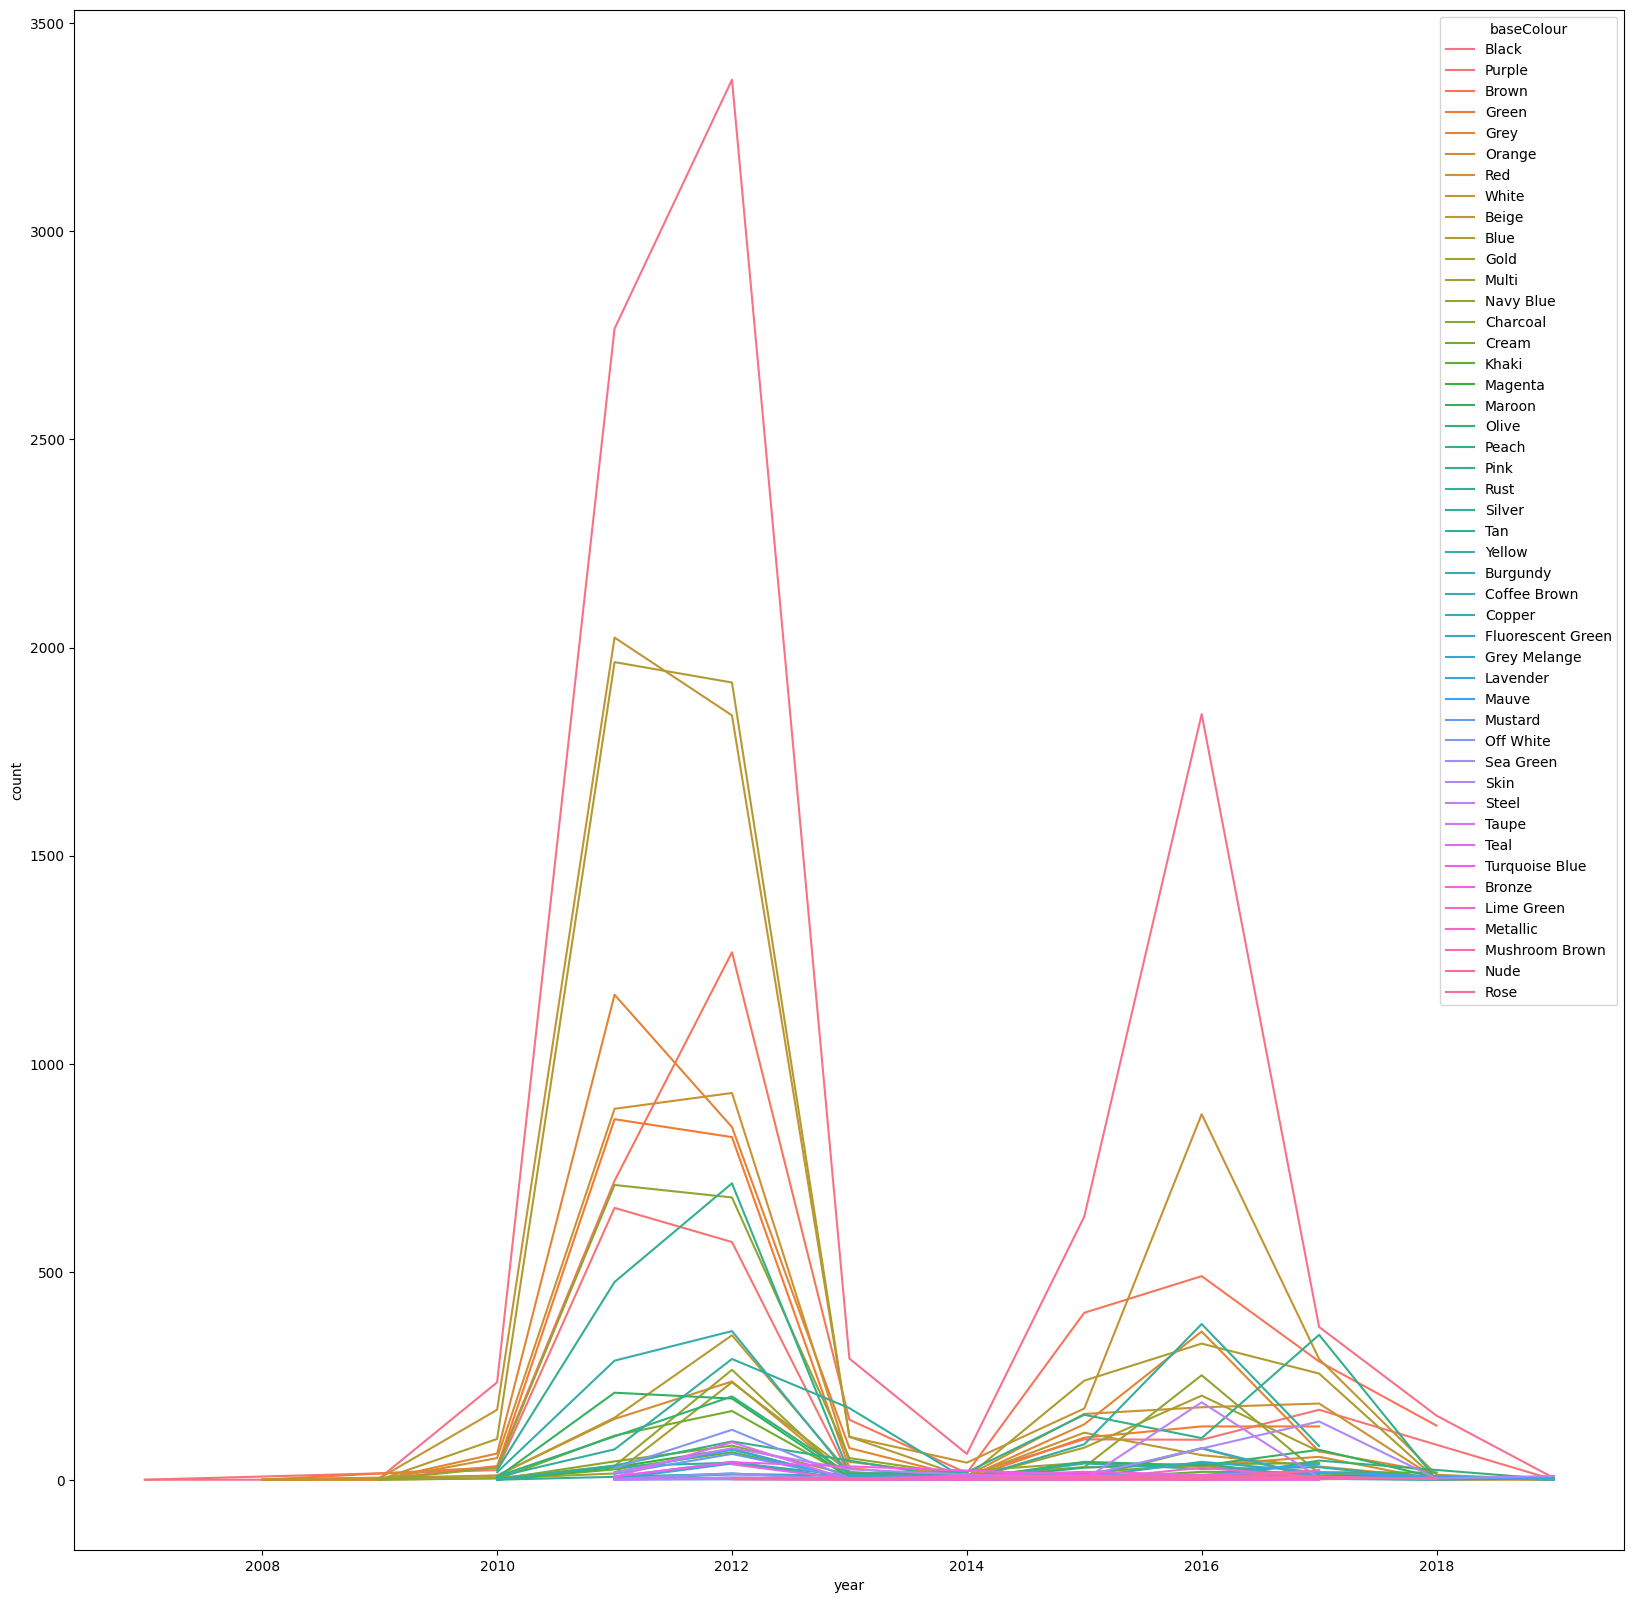

In [18]:
count_data = df.groupby(['year','baseColour']).size().reset_index(name='count')
plt.figure(figsize=(20, 20))
sns.lineplot(data=count_data, x='year', y='count', hue='baseColour', markers=True)

<Axes: xlabel='year', ylabel='count'>

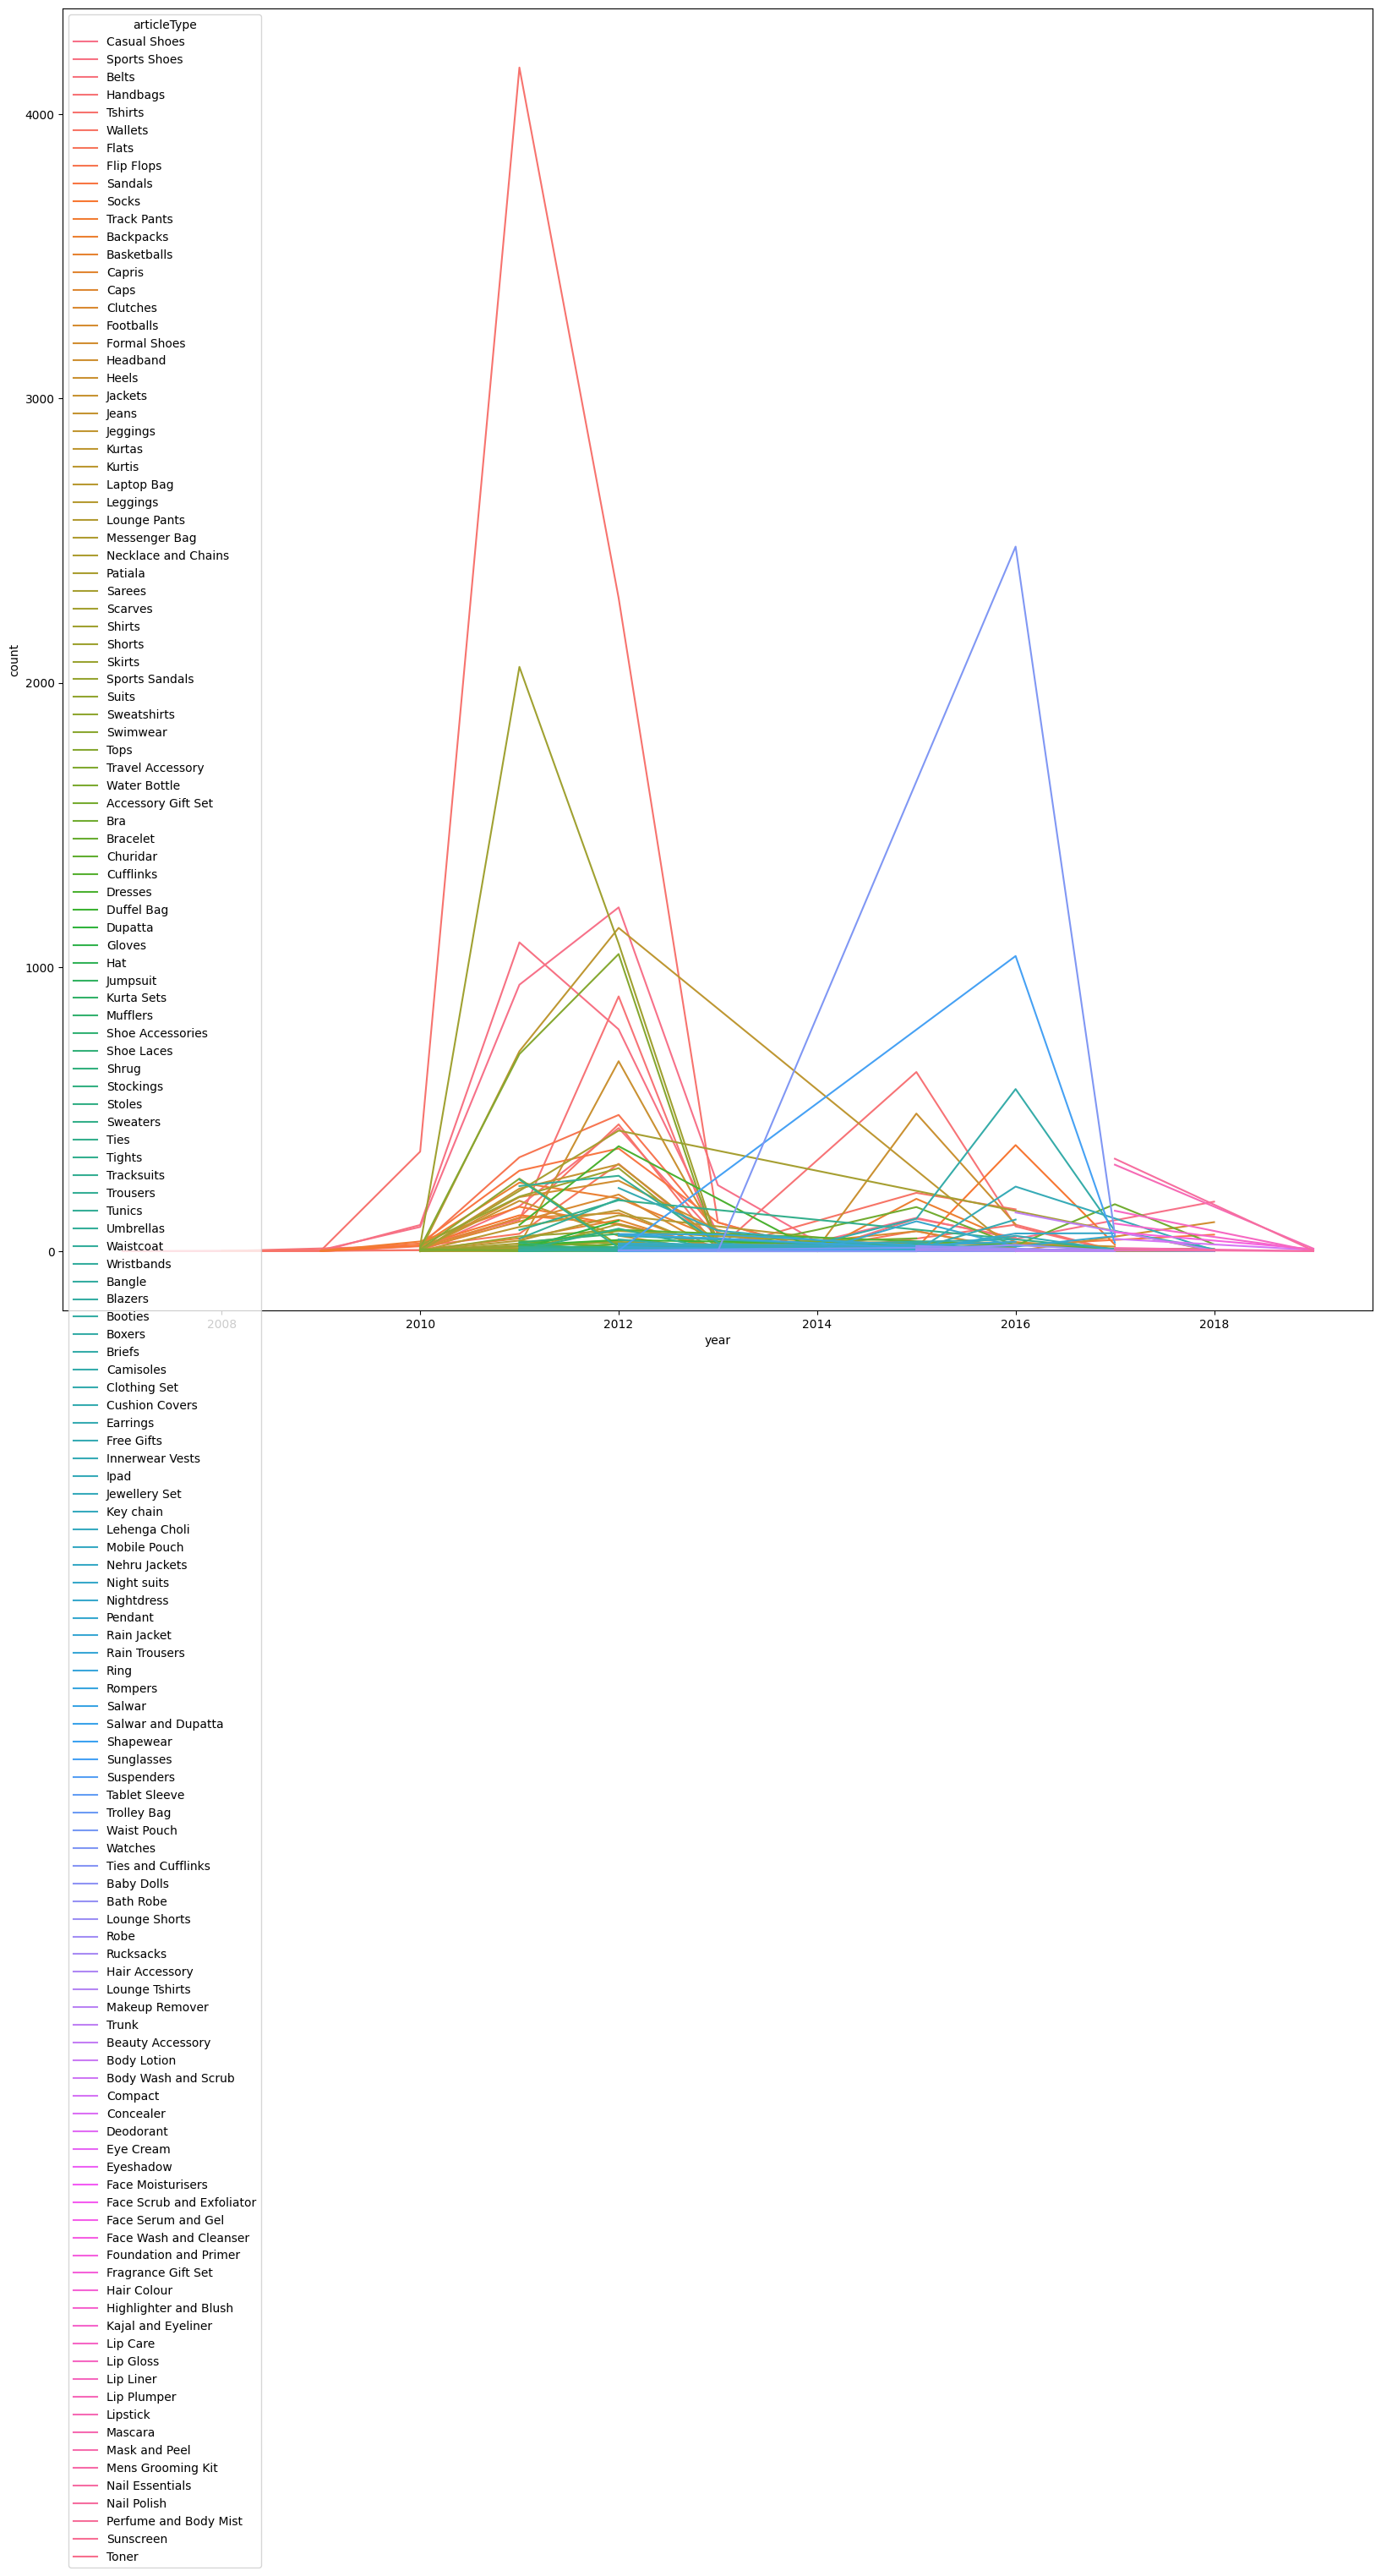

In [20]:
count_data = df.groupby(['year','articleType']).size().reset_index(name='count')
plt.figure(figsize=(20, 20))
sns.lineplot(data=count_data, x='year', y='count', hue='articleType', markers=True)